In [11]:
# cp train_config.json /mnt/lustre-grete/usr/u12045/vla/hf_cache/hub/models--lerobot--pi0/snapshots/8f50aacbe079a026391616cf22453de528f2a873

In [12]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ["PATH"] = "/mnt/lustre-grete/usr/u12045/projects/LLAVA-Med/envs/lerobot/bin:" + os.environ.get("PATH", "")
os.environ["HF_HOME"] = "/mnt/lustre-grete/usr/u12045/vla/hf_cache"
os.environ["TMPDIR"] = "/mnt/lustre-grete/usr/u12045/vla/cache"
os.environ["PYTHONPATH"] = "/mnt/lustre-grete/usr/u12045/vla/duci/VLA-Humanoid:" + os.environ.get("PYTHONPATH", "")
import sys
sys.path.insert(0, "/mnt/lustre-grete/usr/u12045/vla/duci/VLA-Humanoid")

import logging
import time
from contextlib import nullcontext
from pprint import pformat
from typing import Any

import torch
from termcolor import colored
from torch.amp import GradScaler
from torch.optim import Optimizer

from lerobot.common.datasets.factory import make_dataset
from lerobot.common.datasets.sampler import EpisodeAwareSampler
from lerobot.common.datasets.utils import cycle
from lerobot.common.envs.factory import make_env
from lerobot.common.optim.factory import make_optimizer_and_scheduler
from lerobot.common.policies.factory import make_policy
from lerobot.common.policies.pretrained import PreTrainedPolicy
from lerobot.common.policies.utils import get_device_from_parameters
from lerobot.common.utils.logging_utils import AverageMeter, MetricsTracker
from lerobot.common.utils.random_utils import set_seed
from lerobot.common.utils.train_utils import (
    get_step_checkpoint_dir,
    get_step_identifier,
    load_training_state,
    save_checkpoint,
    update_last_checkpoint,
)
from lerobot.common.utils.utils import (
    format_big_number,
    get_safe_torch_device,
    has_method,
    init_logging,
)
from lerobot.common.utils.wandb_utils import WandBLogger
from lerobot.configs import parser
from lerobot.configs.train import TrainPipelineConfig
from lerobot.scripts.eval import eval_policy
from lerobot.common.constants import ACTION, OBS_STATE

import json
from dotenv import load_dotenv
load_dotenv()


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
init_logging()

In [14]:
from lerobot.configs.policies import PreTrainedConfig
from lerobot.configs.default import DatasetConfig, EvalConfig, WandBConfig
from lerobot.common.datasets.transforms import ImageTransformsConfig

with open("../configs/calvin_config/default.json") as f:
    data = json.load(f)
# /mnt/lustre-grete/usr/u12045/vla/hf_cache/lerobot/binhng/libero_spatial_mask_debug_noops_lerobot
cfg = TrainPipelineConfig(
    policy=PreTrainedConfig.from_pretrained("lerobot/pi0"),
    dataset=DatasetConfig(
        repo_id="ducido/calvin_task_D_D_scale_50_lerobo_format",
        image_transforms=ImageTransformsConfig.from_dict(data["dataset"]['image_transforms']),
    ),
    wandb=WandBConfig(
        project="lerobot",
        entity="lerobot",
    ),
)
cfg.validate()
# logging.info(pformat(cfg.to_dict()))

WARNING 2025-07-14 18:57:31 ils/utils.py:52 No accelerated backend detected. Using default cpu, this will be slow.
WARNING 2025-07-14 18:57:31 /policies.py:68 Device 'cuda' is not available. Switching to 'cpu'.


In [15]:
cfg.policy.chunk_size = 10
cfg.policy.n_action_steps = 10
cfg.batch_size = 1
cfg.wandb.enable = False
cfg.dataset.image_transforms.enable = True
cfg.log_freq = 20
cfg.num_steps = 2

In [16]:
if cfg.wandb.enable and cfg.wandb.project:
    wandb_logger = WandBLogger(cfg)
else:
    wandb_logger = None
    logging.info(colored("Logs will be saved locally.", "yellow", attrs=["bold"]))

if cfg.seed is not None:
    set_seed(cfg.seed)

device = get_safe_torch_device(cfg.policy.device, log=True)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True

logging.info("Creating dataset")
dataset = make_dataset(cfg)

INFO 2025-07-20 08:28:53 2197283937.py:5 Logs will be saved locally.
INFO 2025-07-20 08:28:53 197283937.py:14 Creating dataset
WARNING 2025-07-20 08:28:53 ts/utils.py:303 
The dataset you requested (ducido/calvin_task_D_D_scale_50_lerobo_format) is in 2.0 format.
While current version of LeRobot is backward-compatible with it, the version of your dataset still uses global
stats instead of per-episode stats. Update your dataset stats to the new format using this command:
```
python lerobot/common/datasets/v21/convert_dataset_v20_to_v21.py --repo-id=ducido/calvin_task_D_D_scale_50_lerobo_format
```

If you encounter a problem, contact LeRobot maintainers on [Discord](https://discord.com/invite/s3KuuzsPFb)
or open an [issue on GitHub](https://github.com/huggingface/lerobot/issues/new/choose).

WARNING 2025-07-20 08:28:53 ts/utils.py:303 
The dataset you requested (ducido/calvin_task_D_D_scale_50_lerobo_format) is in 2.0 format.
While current version of LeRobot is backward-compatible with 

Resolving data files:   0%|          | 0/2562 [00:00<?, ?it/s]

In [17]:
# Create environment used for evaluating checkpoints during training on simulation data.
# On real-world data, no need to create an environment as evaluations are done outside train.py,
# using the eval.py instead, with gym_dora environment and dora-rs.
eval_env = None
if cfg.eval_freq > 0 and cfg.env is not None:
    logging.info("Creating env")
    eval_env = make_env(cfg.env, n_envs=cfg.eval.batch_size, use_async_envs=cfg.eval.use_async_envs)

In [ ]:
jax_norm_stats

{'state': {'mean': array([ 0.06137776, -0.11410107,  0.50186026,  1.21013367, -0.02636181,
          1.5830574 ,  0.05373131, -0.65109986,  0.9976843 ,  1.74398351,
         -2.00823259, -1.00430524,  1.74444032,  0.56320119, -0.0033571 ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ]),
  'std': array([0.15815794, 0.10150439, 0.05503138, 2.82920384, 0.10528079,
         0.41227192, 0.02931974, 0.29692534, 0.16840713, 0.2437624 ,
         0.38815749, 0.195886  , 0.16290529, 0.39232841, 0.99999434,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        ])},
 'joint_actions': {'mean': array([-0.63466722

In [46]:
import numpy as np
jax_norm_stats = np.load("/mnt/lustre-grete/usr/u12045/vla/duci/VLA-Humanoid/norm_stats_jax.npy", allow_pickle=True).item()
dataset.meta.stats['state']['mean'] = jax_norm_stats['state']['mean'][:15]
dataset.meta.stats['state']['std'] = jax_norm_stats['state']['std'][:15]
dataset.meta.stats['joint_actions']['std'] = jax_norm_stats['joint_actions']['std'][:8]
dataset.meta.stats['joint_actions']['mean'] = jax_norm_stats['joint_actions']['mean'][:8]

In [19]:
cfg.policy.pretrained_path = "/mnt/lustre-grete/usr/u12045/vla/pi0_torch_newcp"


In [20]:
logging.info("Creating policy")
policy = make_policy(
    cfg=cfg.policy,
    ds_meta=dataset.meta,
)


INFO 2025-07-20 08:29:03 1291515003.py:1 Creating policy


load pretrained policy
Loading weights from local directory


In [29]:
policy.config.empty_cameras = 1


In [21]:
logging.info("Creating optimizer and scheduler")
optimizer, lr_scheduler = make_optimizer_and_scheduler(cfg, policy)
grad_scaler = GradScaler(device.type, enabled=cfg.policy.use_amp)

step = 0  # number of policy updates (forward + backward + optim)

if cfg.resume:
    step, optimizer, lr_scheduler = load_training_state(cfg.checkpoint_path, optimizer, lr_scheduler)

num_learnable_params = sum(p.numel() for p in policy.parameters() if p.requires_grad)
num_total_params = sum(p.numel() for p in policy.parameters())

logging.info(colored("Output dir:", "yellow", attrs=["bold"]) + f" {cfg.output_dir}")
if cfg.env is not None:
    logging.info(f"{cfg.env.task=}")
logging.info(f"{cfg.steps=} ({format_big_number(cfg.steps)})")
logging.info(f"{dataset.num_frames=} ({format_big_number(dataset.num_frames)})")
logging.info(f"{dataset.num_episodes=}")
logging.info(f"{num_learnable_params=} ({format_big_number(num_learnable_params)})")
logging.info(f"{num_total_params=} ({format_big_number(num_total_params)})")


INFO 2025-07-20 08:30:01 2797565836.py:1 Creating optimizer and scheduler
INFO 2025-07-20 08:30:01 797565836.py:13 Output dir: outputs/train/2025-07-20/08-28-52_pi0
INFO 2025-07-20 08:30:01 797565836.py:16 cfg.steps=100000 (100K)
INFO 2025-07-20 08:30:01 797565836.py:17 dataset.num_frames=152520 (153K)
INFO 2025-07-20 08:30:01 797565836.py:18 dataset.num_episodes=2562
INFO 2025-07-20 08:30:01 797565836.py:19 num_learnable_params=3088929824 (3B)
INFO 2025-07-20 08:30:01 797565836.py:20 num_total_params=3501372238 (4B)


### why not fully finetune, which part is freezed

In [31]:
# create dataloader for offline training
if hasattr(cfg.policy, "drop_n_last_frames"):
    shuffle = False
    sampler = EpisodeAwareSampler(
        dataset.episode_data_index,
        drop_n_last_frames=cfg.policy.drop_n_last_frames,
        shuffle=True,
    )
else:
    shuffle = True
    sampler = None

dataloader = torch.utils.data.DataLoader(
    dataset,
    num_workers=cfg.num_workers,
    batch_size=cfg.batch_size,
    shuffle=shuffle,
    sampler=sampler,
    pin_memory=device.type != "cpu",
    drop_last=False,
)
dl_iter = cycle(dataloader)

In [23]:
sample = next(dl_iter)

['put the grasped block on top of a block']


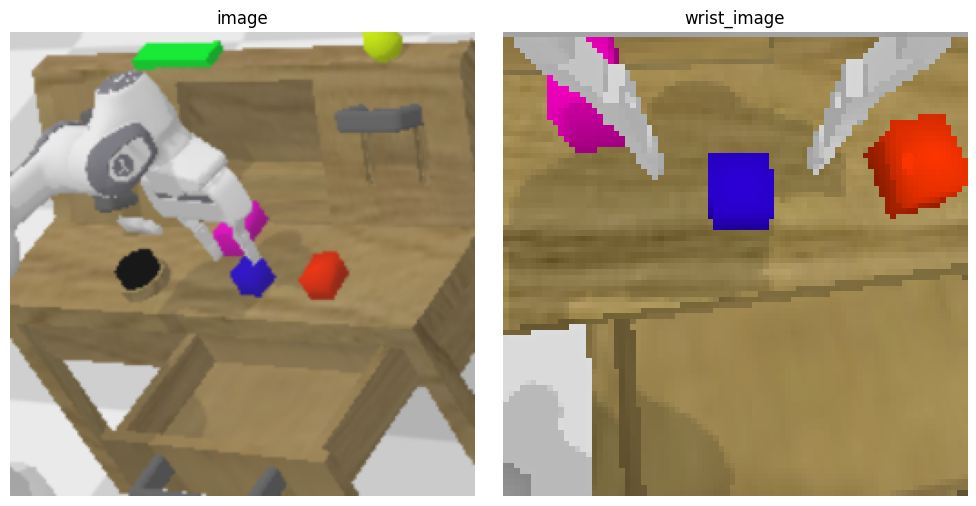

In [25]:
import torch
import matplotlib.pyplot as plt
print(sample['task'])
# Assume sample['image'] and sample['wrist_image'] are tensors of shape (1, 3, H, W)
keys = ['image', 'wrist_image']
n = len(keys)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]  # ensure axes is iterable

for ax, key in zip(axes, keys):
    # Extract the tensor and move channel to last dimension
    img_tensor = sample[key][0]  # shape (3, H, W)
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()  # (H, W, 3)
    
    ax.imshow(img_np)
    ax.set_title(key)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [34]:
def update_policy(
    train_metrics: MetricsTracker,
    policy: PreTrainedPolicy,
    batch: Any,
    optimizer: Optimizer,
    grad_clip_norm: float,
    grad_scaler: GradScaler,
    lr_scheduler=None,
    use_amp: bool = False,
    lock=None,
) -> tuple[MetricsTracker, dict]:
    start_time = time.perf_counter()
    device = get_device_from_parameters(policy)
    policy.train()
    with torch.autocast(device_type=device.type) if use_amp else nullcontext():
        loss, output_dict = policy.forward(batch)
        # TODO(rcadene): policy.unnormalize_outputs(out_dict)
    print(output_dict.keys())
    grad_scaler.scale(loss).backward()

    # Unscale the gradient of the optimizer's assigned params in-place **prior to gradient clipping**.
    grad_scaler.unscale_(optimizer)

    grad_norm = torch.nn.utils.clip_grad_norm_(
        policy.parameters(),
        grad_clip_norm,
        error_if_nonfinite=False,
    )

    # Optimizer's gradients are already unscaled, so scaler.step does not unscale them,
    # although it still skips optimizer.step() if the gradients contain infs or NaNs.
    with lock if lock is not None else nullcontext():
        grad_scaler.step(optimizer)
    # Updates the scale for next iteration.
    grad_scaler.update()

    optimizer.zero_grad()

    # Step through pytorch scheduler at every batch instead of epoch
    if lr_scheduler is not None:
        lr_scheduler.step()

    if has_method(policy, "update"):
        # To possibly update an internal buffer (for instance an Exponential Moving Average like in TDMPC).
        policy.update()

    train_metrics.loss = loss.item()
    train_metrics.grad_norm = grad_norm.item()
    train_metrics.lr = optimizer.param_groups[0]["lr"]
    train_metrics.update_s = time.perf_counter() - start_time
    return train_metrics, output_dict



policy.train()

train_metrics = {
    "loss": AverageMeter("loss", ":.3f"),
    "grad_norm": AverageMeter("grdn", ":.3f"),
    "lr": AverageMeter("lr", ":0.1e"),
    "update_s": AverageMeter("updt_s", ":.3f"),
    "dataloading_s": AverageMeter("data_s", ":.3f"),
}

train_tracker = MetricsTracker(
    cfg.batch_size, dataset.num_frames, dataset.num_episodes, train_metrics, initial_step=step
)

logging.info("Start offline training on a fixed dataset")
for _ in range(step, cfg.steps):
    start_time = time.perf_counter()
    batch = next(dl_iter)
    train_tracker.dataloading_s = time.perf_counter() - start_time

    for key in batch:
        if isinstance(batch[key], torch.Tensor):
            batch[key] = batch[key].to(device, non_blocking=True)

    train_tracker, output_dict = update_policy(
        train_tracker,
        policy,
        batch,
        optimizer,
        cfg.optimizer.grad_clip_norm,
        grad_scaler=grad_scaler,
        lr_scheduler=lr_scheduler,
        use_amp=cfg.policy.use_amp,
    )

    # Note: eval and checkpoint happens *after* the `step`th training update has completed, so we
    # increment `step` here.
    step += 1
    train_tracker.step()
    is_log_step = cfg.log_freq > 0 and step % cfg.log_freq == 0
    is_saving_step = step % cfg.save_freq == 0 or step == cfg.steps
    is_eval_step = cfg.eval_freq > 0 and step % cfg.eval_freq == 0

    if is_log_step:
        ###### compute l1 loss
        print("ductop1")
        pred = policy.select_action_chunk(batch)
        print(pred[:,-1].min(), pred[:,-1].max())
        pred[:,:,-1] = torch.where(pred[:,:,-1] > 0, torch.tensor(1.0, device=device), torch.tensor(-1.0, device=device))
        gt = batch[ACTION]
        print(gt[:,-1].min(), gt[:,-1].max())
        assert pred.shape == gt.shape, f"Pred shape {pred.shape} does not match GT shape {gt.shape}"
        l1_infer_loss = torch.nn.functional.l1_loss(pred, gt)
        ######

        logging.info(train_tracker)
        if wandb_logger:
            wandb_log_dict = train_tracker.to_dict()
            if output_dict:
                wandb_log_dict.update(output_dict)
            wandb_logger.log_dict(wandb_log_dict, step)
        train_tracker.reset_averages()

    if cfg.save_checkpoint and is_saving_step:
        logging.info(f"Checkpoint policy after step {step}")
        checkpoint_dir = get_step_checkpoint_dir(cfg.output_dir, cfg.steps, step)
        save_checkpoint(checkpoint_dir, step, cfg, policy, optimizer, lr_scheduler)
        update_last_checkpoint(checkpoint_dir)
        if wandb_logger:
            wandb_logger.log_policy(checkpoint_dir)
        print(wandb_logger)

    if cfg.env and is_eval_step:
        step_id = get_step_identifier(step, cfg.steps)
        logging.info(f"Eval policy at step {step}")
        with (
            torch.no_grad(),
            torch.autocast(device_type=device.type) if cfg.policy.use_amp else nullcontext(),
        ):
            eval_info = eval_policy(
                eval_env,
                policy,
                cfg.eval.n_episodes,
                videos_dir=cfg.output_dir / "eval" / f"videos_step_{step_id}",
                max_episodes_rendered=4,
                start_seed=cfg.seed,
            )

        eval_metrics = {
            "avg_sum_reward": AverageMeter("∑rwrd", ":.3f"),
            "pc_success": AverageMeter("success", ":.1f"),
            "eval_s": AverageMeter("eval_s", ":.3f"),
        }
        eval_tracker = MetricsTracker(
            cfg.batch_size, dataset.num_frames, dataset.num_episodes, eval_metrics, initial_step=step
        )
        eval_tracker.eval_s = eval_info["aggregated"].pop("eval_s")
        eval_tracker.avg_sum_reward = eval_info["aggregated"].pop("avg_sum_reward")
        eval_tracker.pc_success = eval_info["aggregated"].pop("pc_success")
        logging.info(eval_tracker)
        if wandb_logger:
            wandb_log_dict = {**eval_tracker.to_dict(), **eval_info}
            wandb_logger.log_dict(wandb_log_dict, step, mode="eval")
            wandb_logger.log_video(eval_info["video_paths"][0], step, mode="eval")

if eval_env:
    eval_env.close()
logging.info("End of training")



INFO 2025-07-20 08:35:03 427293502.py:69 Start offline training on a fixed dataset


3
3
dict_keys(['losses_after_forward', 'losses_after_rm_padding', 'l2_loss'])
ductop1
2
2


INFO 2025-07-20 08:35:04 27293502.py:110 step:40 smpl:40 ep:1 epch:0.00 loss:0.275 grdn:8.132 lr:4.2e-06 updt_s:0.271 data_s:0.000


tensor(-0.7322, device='cuda:0') tensor(0.9618, device='cuda:0')
tensor(-1.5657, device='cuda:0') tensor(1.5811, device='cuda:0')
3
3
dict_keys(['losses_after_forward', 'losses_after_rm_padding', 'l2_loss'])
3
3
dict_keys(['losses_after_forward', 'losses_after_rm_padding', 'l2_loss'])
3
3
dict_keys(['losses_after_forward', 'losses_after_rm_padding', 'l2_loss'])
3
3
dict_keys(['losses_after_forward', 'losses_after_rm_padding', 'l2_loss'])
3
3
dict_keys(['losses_after_forward', 'losses_after_rm_padding', 'l2_loss'])
3
3
dict_keys(['losses_after_forward', 'losses_after_rm_padding', 'l2_loss'])
3
3
dict_keys(['losses_after_forward', 'losses_after_rm_padding', 'l2_loss'])
3
3
dict_keys(['losses_after_forward', 'losses_after_rm_padding', 'l2_loss'])
3
3
dict_keys(['losses_after_forward', 'losses_after_rm_padding', 'l2_loss'])
3
3
dict_keys(['losses_after_forward', 'losses_after_rm_padding', 'l2_loss'])


KeyboardInterrupt: 

In [23]:
cfg.policy.chunk_size, cfg.policy.n_action_steps

(10, 10)

In [ ]:
from collections import deque
total_loss = []
for batch in dl_iter:
    for key in batch:
        if isinstance(batch[key], torch.Tensor):
            batch[key] = batch[key].to(device, non_blocking=True)
    with torch.no_grad():
        policy._action_queue = deque()
        pred = policy.select_action_chunk(batch)
        pred = pred[:,0,:].unsqueeze(1)
    pred[:,:,-1] = torch.where(
            pred[:,:,-1] > 0, torch.tensor(1.0, device=device), torch.tensor(-1.0, device=device)
        )
    print(pred.shape)
    gt = batch[ACTION][:,0,:].unsqueeze(1)

    assert pred.shape == gt.shape, f"Pred shape {pred.shape} does not match GT shape {gt.shape}"
    loss = torch.nn.functional.mse_loss(pred, gt)
    total_loss.append(loss.item())
    if len(total_loss) % 10 == 0:
        print('pred')
        print(pred)
        print('gt')
        print(gt)
        print('average l2 loss', sum(total_loss) / len(total_loss))
        break
